In [21]:
!pip install evidently
!pip install pyspark==3.0.2
# !pip install findspark
!pip install pydoop

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 673 kB 1.8 MB/s eta 0:00:01
  Created wheel for pydoop: filename=pydoop-2.0.0-cp38-cp38-linux_x86_64.whl size=754103 sha256=2b19149d67ac0c8fb7e280ddb97f6d3882069b706295afc52772fa7c89e7931d
  Stored in directory: /home/ubuntu/.cache/pip/wheels/06/45/30/fb9bd5fec2de531d3d776eecce066dc9cc282c077991c5c2ad
Successfully built pydoop
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import subprocess
from subprocess import check_call

import pandas as pd
import pyspark.sql.functions as spark_f
from pyspark.sql import SparkSession
from pyspark.sql.types import IntegerType,BooleanType,DateType,FloatType

In [2]:
def distcp(from_path: str, to_path: str) -> None:
    check_call(['hadoop', 'distcp', from_path, to_path], stderr=subprocess.STDOUT)

In [6]:
# distcp('s3a://ap-golovko-otus-hw3-bucket/preprocessed/', './preprocessed/')

In [3]:
spark = SparkSession.builder.appName("OTUS-HW3").getOrCreate()

# EDA части датасета

In [6]:
!hdfs dfs -ls preprocessed

Found 1 items
drwxr-xr-x   - ubuntu hadoop          0 2024-10-22 10:33 preprocessed/preprocessed


In [7]:
sdf_part = spark.read.parquet('preprocessed/preprocessed/2019-08-22.parquet')

In [8]:
sdf_part.show()

+-------------+-------------------+-----------+-----------+---------+---------------+------------+--------+-----------------+
|tranaction_id|        tx_datetime|customer_id|terminal_id|tx_amount|tx_time_seconds|tx_time_days|tx_fraud|tx_fraud_scenario|
+-------------+-------------------+-----------+-----------+---------+---------------+------------+--------+-----------------+
|      9346933|2019-08-27 14:32:09|     967548|        207|    70.78|         484329|           5|       0|                0|
|      9346934|2019-08-27 04:30:21|     967549|        919|    99.07|         448221|           5|       0|                0|
|      9346935|2019-08-27 23:02:17|     967549|        914|    42.43|         514937|           5|       0|                0|
|      9346936|2019-08-27 16:12:06|     967549|        110|    10.09|         490326|           5|       0|                0|
|      9346937|2019-08-27 23:03:37|     967550|        114|    16.62|         515017|           5|       0|           

In [9]:
sdf_part.dtypes

[('tranaction_id', 'string'),
 ('tx_datetime', 'string'),
 ('customer_id', 'string'),
 ('terminal_id', 'string'),
 ('tx_amount', 'string'),
 ('tx_time_seconds', 'string'),
 ('tx_time_days', 'string'),
 ('tx_fraud', 'string'),
 ('tx_fraud_scenario', 'string')]

In [10]:
sdf_part = sdf_part.withColumn("tranaction_id",sdf_part.tranaction_id.cast(IntegerType()))
sdf_part = sdf_part.withColumn("customer_id",sdf_part.customer_id.cast(IntegerType()))
sdf_part = sdf_part.withColumn("terminal_id",sdf_part.terminal_id.cast(IntegerType()))
sdf_part = sdf_part.withColumn("tx_time_seconds",sdf_part.tx_time_seconds.cast(IntegerType()))
sdf_part = sdf_part.withColumn("tx_time_days",sdf_part.tx_time_days.cast(IntegerType()))
sdf_part = sdf_part.withColumn("tranacttx_fraudion_id",sdf_part.tx_fraud.cast(IntegerType()))
sdf_part = sdf_part.withColumn("tx_fraud_scenario",sdf_part.tx_fraud_scenario.cast(IntegerType()))

sdf_part = sdf_part.withColumn("tx_amount",sdf_part.tx_amount.cast(FloatType()))

In [11]:
sdf_part.dtypes

[('tranaction_id', 'int'),
 ('tx_datetime', 'string'),
 ('customer_id', 'int'),
 ('terminal_id', 'int'),
 ('tx_amount', 'float'),
 ('tx_time_seconds', 'int'),
 ('tx_time_days', 'int'),
 ('tx_fraud', 'string'),
 ('tx_fraud_scenario', 'int'),
 ('tranacttx_fraudion_id', 'int')]

In [12]:
sdf_part.summary().show()

+-------+--------------------+-------------------+------------------+------------------+------------------+------------------+-----------------+-------------------+-------------------+---------------------+
|summary|       tranaction_id|        tx_datetime|       customer_id|       terminal_id|         tx_amount|   tx_time_seconds|     tx_time_days|           tx_fraud|  tx_fraud_scenario|tranacttx_fraudion_id|
+-------+--------------------+-------------------+------------------+------------------+------------------+------------------+-----------------+-------------------+-------------------+---------------------+
|  count|            46988418|           46988418|          46988418|          46988418|          46988418|          46988418|         46988418|           46988418|           46988418|             46988418|
|   mean|2.3494115552178305E7|               null|500433.83151635365|26597.231571533222| 54.23395999449798|1296054.5003670265| 14.5006346883183|0.05377931642644364|0.108415

In [14]:
sdf_part.select([spark_f.count(spark_f.when(spark_f.isnan(c) | spark_f.col(c).isNull(), c)).alias(c) for c in sdf_part.columns]).show()

+-------------+-----------+-----------+-----------+---------+---------------+------------+--------+-----------------+---------------------+
|tranaction_id|tx_datetime|customer_id|terminal_id|tx_amount|tx_time_seconds|tx_time_days|tx_fraud|tx_fraud_scenario|tranacttx_fraudion_id|
+-------------+-----------+-----------+-----------+---------+---------------+------------+--------+-----------------+---------------------+
|            0|          0|          0|          0|        0|              0|           0|       0|                0|                    0|
+-------------+-----------+-----------+-----------+---------+---------------+------------+--------+-----------------+---------------------+



Дубли в ID транзакции

In [15]:
(
    sdf_part.groupBy(['tranaction_id'])
    .count()
    .where(spark_f.col('count') > 1)
    .select(spark_f.sum('count'))
    .show()
)

+----------+
|sum(count)|
+----------+
|       362|
+----------+



Отрицательные customer ID

In [16]:
sdf_part.where(spark_f.col('customer_id') < 0).count()

64

Выбросы в поле frequency

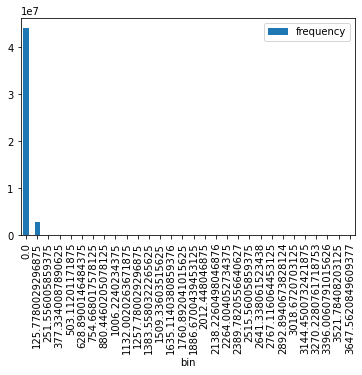

In [17]:
hist = sdf_part.select('tx_amount').rdd.flatMap(lambda x: x).histogram(30)

pd.DataFrame(
    list(zip(*hist)), 
    columns=['bin', 'frequency']
).set_index(
    'bin'
).plot(kind='bar')

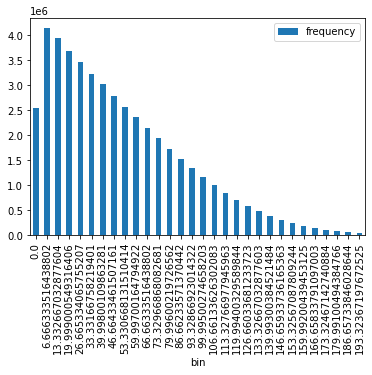

In [17]:
hist = sdf_part.where(spark_f.col('tx_amount') < 200).select('tx_amount').rdd.flatMap(lambda x: x).histogram(30)

pd.DataFrame(
    list(zip(*hist)), 
    columns=['bin', 'frequency']
).set_index(
    'bin'
).plot(kind='bar')

In [18]:
sdf_part.where(spark_f.col('tx_amount') > 200).count()

127587

In [19]:
sdf_part.where(spark_f.col('tx_amount') > 200).count() / sdf_part.count() * 100

0.27152861371072334

## Подсчет на всем датасете

In [22]:
from pathlib import Path
import pydoop.hdfs as hdfs

def get_list_of_file_path(path):
    return [str(Path(path) / file_path.split(path)[1]) for file_path in hdfs.ls(path)]

In [24]:
sdf = spark.read.parquet(*get_list_of_file_path('preprocessed/preprocessed/'), mergeSchema=True)

In [26]:
sdf = sdf.withColumn("tranaction_id",sdf.tranaction_id.cast(IntegerType()))
sdf = sdf.withColumn("customer_id",sdf.customer_id.cast(IntegerType()))
sdf = sdf.withColumn("terminal_id",sdf.terminal_id.cast(IntegerType()))
sdf = sdf.withColumn("tx_time_seconds",sdf.tx_time_seconds.cast(IntegerType()))
sdf = sdf.withColumn("tx_time_days",sdf.tx_time_days.cast(IntegerType()))
sdf = sdf.withColumn("tranacttx_fraudion_id",sdf.tx_fraud.cast(IntegerType()))
sdf = sdf.withColumn("tx_fraud_scenario",sdf.tx_fraud_scenario.cast(IntegerType()))

sdf = sdf.withColumn("tx_amount",sdf.tx_amount.cast(FloatType()))

In [30]:
sdf.count()

1879794138

In [27]:
(
    sdf.groupBy(['tranaction_id'])
    .count()
    .where(spark_f.col('count') > 1)
    .select(spark_f.sum('count'))
    .show()
)

+----------+
|sum(count)|
+----------+
|      5106|
+----------+



In [31]:
5106 / sdf.count() * 100

0.00027162548796074603

In [32]:
sdf.where(spark_f.col('customer_id') < 0).count() / sdf.count() * 100

0.0007779043302878945

In [29]:
sdf.where(spark_f.col('tx_amount') > 200).count() / sdf.count() * 100

0.26908707170359314

## Чистка данных

Учитывая, что найденные проблемы представлены менее чем в 1% датасета, логичнее будет их просто выкинуть, на общем объеме данных для обучения это не скажется.

In [33]:
sdf = sdf.dropDuplicates(['tranaction_id'])

In [34]:
sdf = sdf.where(spark_f.col('customer_id') >= 0)

In [35]:
sdf = sdf.where(spark_f.col('tx_amount') <= 200)

In [36]:
sdf.count()

1874718720